In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation de données GNSS-TEC (séries temporelles)
# L'article utilise des fenêtres de 60 minutes[cite: 423].
# À un taux d'échantillonnage de 30s (comme pour Tohoku [cite: 115]), cela fait 120 points.

def generate_mock_data(n_samples=1000, window_size=120):
    X = []
    y = []
    t = np.linspace(0, 4*np.pi, window_size)
    
    for _ in range(n_samples):
        # Bruit de fond (Classe 'Normal')
        noise = np.random.normal(0, 0.1, window_size)
        trend = np.linspace(0, np.random.choice([-0.5, 0.5]), window_size)
        signal = noise + trend
        label = 0 # Normal
        
        # Injection d'anomalie (Classe 'TID' - Perturbation)
        # Les TIDs ressemblent à des ondes[cite: 23].
        if np.random.rand() > 0.8: # 20% d'anomalies
            wave = 0.5 * np.sin(t + np.random.uniform(0, 2*np.pi))
            signal += wave
            label = 1 # Anomalous
            
        X.append(signal)
        y.append(label)
        
    return np.array(X), np.array(y)

X_train, y_train = generate_mock_data(n_samples=500)
print(f"Forme des données: {X_train.shape}")

Forme des données: (500, 120)


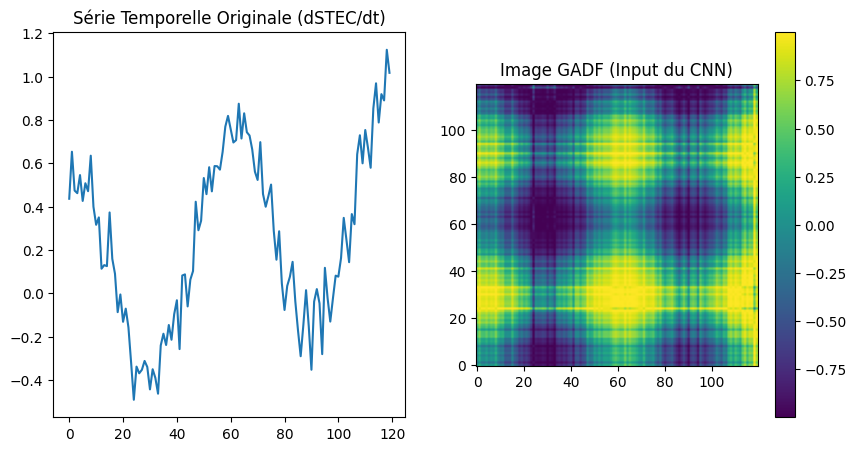

In [7]:
from pyts.image import GramianAngularField

# Cellule : Transformation GADF
# L'image_size=224 est requise pour ResNet, mais si la série temporelle est courte (120 points), 
# on peut utiliser 'method=summation' ou interpoler. 
# Ici, on mappe la longueur de la série à la taille de l'image.

gadf = GramianAngularField(image_size=120, method='difference')

# Transformation d'un échantillon pour visualisation (comme Figure 2 et 3 du papier)
X_gadf = gadf.fit_transform(X_train)

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(X_train[0])
plt.title("Série Temporelle Originale (dSTEC/dt)")
plt.subplot(122)
plt.imshow(X_gadf[0], cmap='viridis', origin='lower')
plt.title("Image GADF (Input du CNN)")
plt.colorbar()
plt.show()

In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet50
from torch.utils.data import TensorDataset, DataLoader

# Configuration du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Préparation des tenseurs
# Les images GADF sont monochromes (1 canal), mais ResNet attend souvent 3 canaux (RGB).
# Une astuce courante est de dupliquer le canal ou modifier la première couche convolutionnelle.
tensor_x = torch.Tensor(X_gadf).unsqueeze(1).repeat(1, 3, 1, 1) # (N, 3, 224, 224)
tensor_y = torch.Tensor(y_train).long()

dataset = TensorDataset(tensor_x, tensor_y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True) # Papier utilise batch=512 

# Initialisation du modèle ResNet50
model = resnet50(pretrained='weights') # 
model.fc = nn.Linear(model.fc.in_features, 2) # 2 classes : Normal vs Anomalie
model = model.to(device)

# Paramètres d'entraînement du papier 
optimizer = torch.optim.Adam(model.parameters(), lr=0.00025)
criterion = nn.CrossEntropyLoss()

/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/dakoro/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 62.0MB/s]


In [10]:
# Cellule : Entraînement basique
num_epochs = 5 # Réduit pour la démo, mettre 50 pour reproduction

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader):.4f}")

Epoch 1/5, Loss: 0.1409
Epoch 2/5, Loss: 0.0120
Epoch 3/5, Loss: 0.0184
Epoch 4/5, Loss: 0.0005
Epoch 5/5, Loss: 0.0006


In [11]:
def false_positive_mitigation(predictions_dict, threshold=0.75):
    """
    Simule la stratégie de mitigation.
    
    predictions_dict: dictionnaire où la clé est l'ID du satellite et 
                      la valeur est une liste de booléens (1 pour détection TID, 0 sinon)
                      provenant de différentes stations au sol pour le même instant.
    """
    mitigated_results = {}
    
    for satellite_id, station_preds in predictions_dict.items():
        # Calcul du score pondéré F_{s,t} [cite: 400]
        score = sum(station_preds) / len(station_preds)
        
        # Application du seuil [cite: 401]
        is_confirmed_tid = score > threshold
        mitigated_results[satellite_id] = {
            "score": score,
            "confirmed": is_confirmed_tid
        }
        
    return mitigated_results

# Exemple d'utilisation
# Imaginons que pour le satellite G12, nous avons 10 stations au sol.
# 8 stations détectent une anomalie (1), 2 ne détectent rien (0).
simulated_preds = {
    "G12": [1, 1, 1, 1, 1, 1, 1, 1, 0, 0], # 80% de détection
    "G24": [1, 0, 0, 0, 1, 0, 0, 0, 0, 0]  # 20% de détection (bruit probable)
}

results = false_positive_mitigation(simulated_preds)
print("Résultats après mitigation:", results)

Résultats après mitigation: {'G12': {'score': 0.8, 'confirmed': True}, 'G24': {'score': 0.2, 'confirmed': False}}


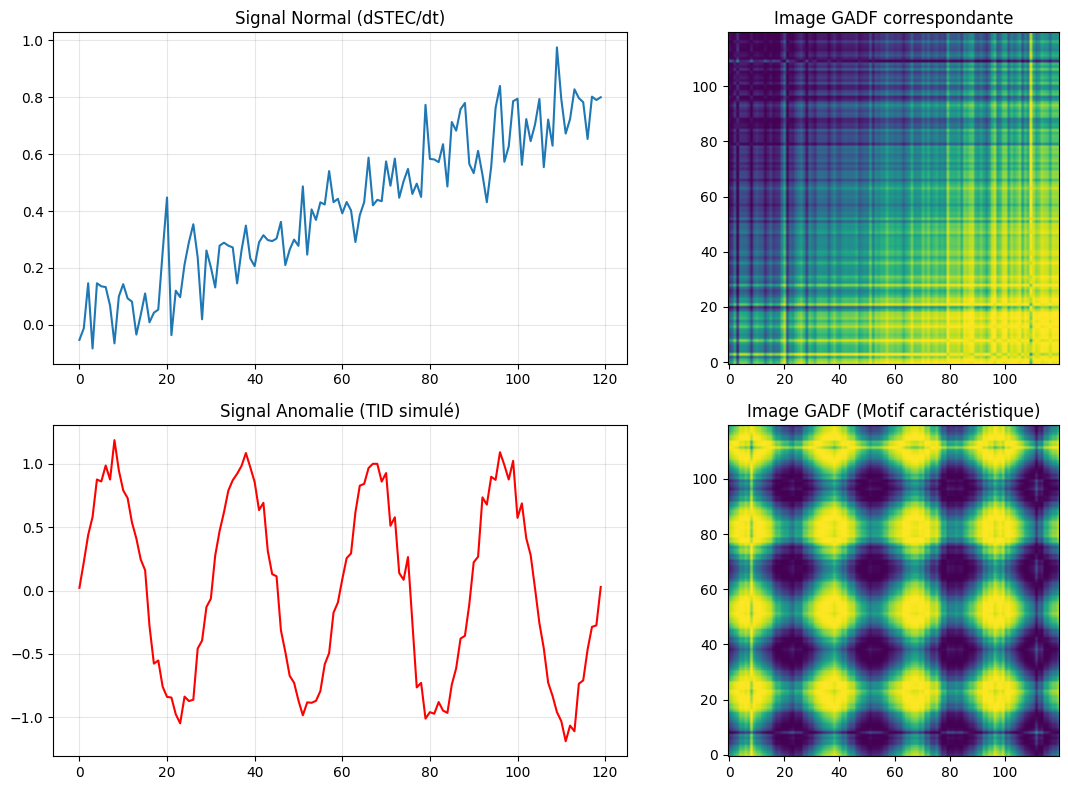

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField

# 1. Simulation de données distinctes
def generate_specific_samples(size=120):
    # Cas Normal: Bruit aléatoire + légère tendance
    x = np.linspace(0, 4, size)
    normal_signal = 0.1 * np.random.randn(size) + 0.2 * x
    
    # Cas Anomalie (TID): Sinusoïde marquée (Onde de gravité)
    # Les TIDs sont souvent des ondes quasi-périodiques
    anomaly_signal = 0.1 * np.random.randn(size) + np.sin(2 * np.pi * x)
    
    return normal_signal.reshape(1, -1), anomaly_signal.reshape(1, -1)

X_normal, X_anomaly = generate_specific_samples()

# 2. Transformation GADF
# Le papier redimensionne souvent les images, mais ici on garde la taille native pour la clarté
gadf = GramianAngularField(image_size=120, method='difference')
img_normal = gadf.fit_transform(X_normal)[0]
img_anomaly = gadf.fit_transform(X_anomaly)[0]

# 3. Affichage Comparatif
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Ligne 1 : Normal
axs[0, 0].plot(X_normal[0])
axs[0, 0].set_title("Signal Normal (dSTEC/dt)")
axs[0, 0].grid(True, alpha=0.3)
im1 = axs[0, 1].imshow(img_normal, cmap='viridis', origin='lower')
axs[0, 1].set_title("Image GADF correspondante")

# Ligne 2 : Anomalie
axs[1, 0].plot(X_anomaly[0], color='r')
axs[1, 0].set_title("Signal Anomalie (TID simulé)")
axs[1, 0].grid(True, alpha=0.3)
im2 = axs[1, 1].imshow(img_anomaly, cmap='viridis', origin='lower')
axs[1, 1].set_title("Image GADF (Motif caractéristique)")

plt.tight_layout()
plt.show()

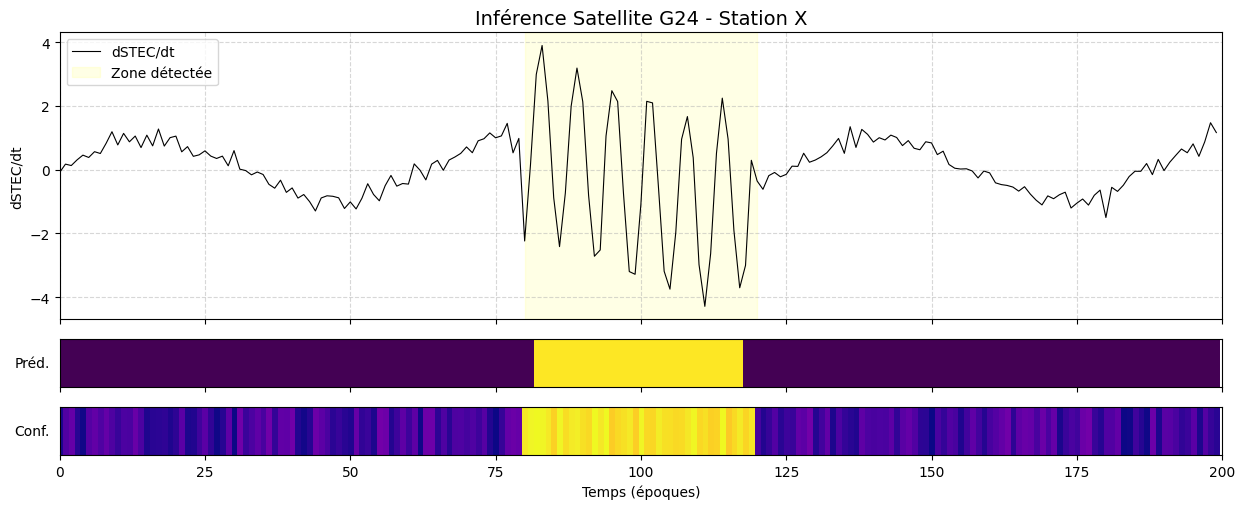

In [13]:
import matplotlib.gridspec as gridspec

def plot_inference_figure(signal, prediction_mask, confidence_score, title="Inférence Satellite G24 - Station X"):
    """
    Reproduit le style de la Figure 4 du papier.
    
    signal: array 1D (le dSTEC/dt)
    prediction_mask: array 1D de booléens (0 ou 1)
    confidence_score: array 1D (flottants entre 0 et 1, ou incertitude)
    """
    
    # Configuration de la grille (Signal en haut, bandes en bas)
    fig = plt.figure(figsize=(15, 6))
    gs = gridspec.GridSpec(4, 1, height_ratios=[3, 0.5, 0.5, 0.2])
    
    # 1. Le Signal Brut
    ax0 = plt.subplot(gs[0])
    ax0.plot(signal, color='black', linewidth=0.8, label='dSTEC/dt')
    ax0.set_title(title, fontsize=14)
    ax0.set_ylabel("dSTEC/dt")
    ax0.set_xlim(0, len(signal))
    ax0.grid(True, linestyle='--', alpha=0.5)
    
    # On ajoute des zones grisées verticales pour aider la lecture (optionnel)
    ax0.axvspan(80, 120, color='yellow', alpha=0.1, label='Zone détectée')
    ax0.legend(loc='upper left')
    
    # 2. Bande de Prédiction (Jaune = Anomalie, Bleu = Normal)
    # Le papier utilise souvent Jaune pour l'anomalie.
    ax1 = plt.subplot(gs[1], sharex=ax0)
    # On étend le masque pour qu'il soit affichable via imshow
    pred_viz = prediction_mask.reshape(1, -1)
    ax1.imshow(pred_viz, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax1.set_yticks([])
    ax1.set_ylabel("Préd.", rotation=0, labelpad=20, va='center')
    
    # 3. Bande de Confiance (Plus c'est jaune, plus c'est incertain ou intense selon le papier)
    ax2 = plt.subplot(gs[2], sharex=ax0)
    conf_viz = confidence_score.reshape(1, -1)
    ax2.imshow(conf_viz, aspect='auto', cmap='plasma') # Plasma pour changer un peu
    ax2.set_yticks([])
    ax2.set_ylabel("Conf.", rotation=0, labelpad=20, va='center')
    
    # Suppression des labels X sauf pour le bas
    plt.setp(ax0.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    plt.xlabel("Temps (époques)")
    plt.show()

# Génération de fausses données pour tester la visualisation
t = np.linspace(0, 200, 200)
mock_signal = np.sin(t/10) + np.random.normal(0, 0.2, 200)
# Création d'une "anomalie" artificielle au centre
mock_signal[80:120] += 3 * np.sin(t[80:120]) 

# Prédiction simulée (1 là où il y a l'anomalie, 0 sinon)
mock_pred = np.zeros_like(t)
mock_pred[82:118] = 1 # Légèrement décalé pour le réalisme

# Confiance simulée (bruitée)
mock_conf = np.random.rand(200) * 0.2
mock_conf[80:120] = 0.8 + 0.1 * np.random.rand(40)

plot_inference_figure(mock_signal, mock_pred, mock_conf)

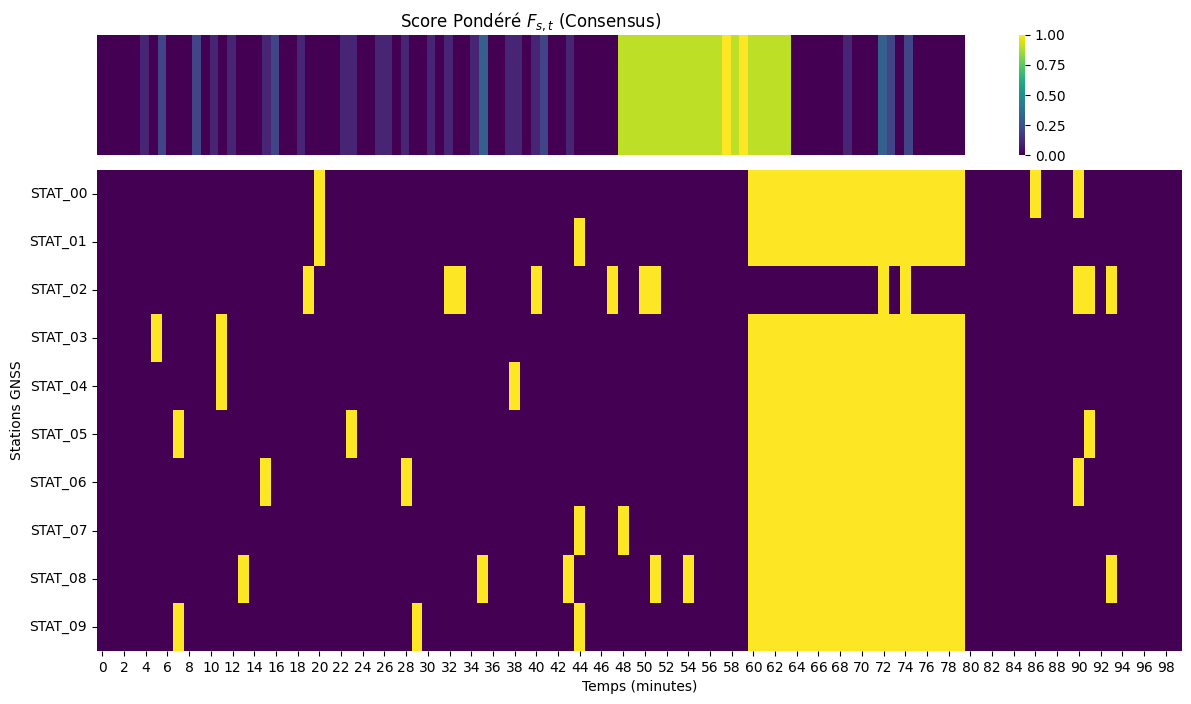

In [14]:
import seaborn as sns

def plot_mitigation_heatmap(predictions_matrix, stations_labels):
    """
    Reproduit la Figure 6 : Heatmap des prédictions + Score pondéré au-dessus.
    
    predictions_matrix: shape (n_stations, n_time_steps) - contient 0 ou 1
    stations_labels: liste des noms des stations
    """
    n_stations, n_steps = predictions_matrix.shape
    
    # 1. Calcul du score pondéré (Moyenne verticale)
    # Formule du papier: somme des détections / nombre de stations
    weighted_score = np.mean(predictions_matrix, axis=0)
    
    # Création de la figure avec deux zones (Score en haut, Heatmap en bas)
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.05)
    
    # A. Le Score Pondéré (Barre du haut)
    ax0 = plt.subplot(gs[0])
    # On l'affiche comme une heatmap 1D pour coller au style du papier
    sns.heatmap(weighted_score.reshape(1, -1), ax=ax0, cmap='viridis', 
                cbar=True, vmin=0, vmax=1, xticklabels=False, yticklabels=False)
    ax0.set_title(r"Score Pondéré $F_{s,t}$ (Consensus)", fontsize=12)
    
    # Ajout d'une ligne pour marquer un seuil potentiel (ex: 0.75)
    # Note: Difficile à voir sur une heatmap, on pourrait utiliser un plot classique ici aussi
    
    # B. La Matrice de Prédictions (Stations vs Temps)
    ax1 = plt.subplot(gs[1])
    sns.heatmap(predictions_matrix, ax=ax1, cmap='viridis', cbar=False,
                yticklabels=stations_labels, vmin=0, vmax=1)
    
    ax1.set_ylabel("Stations GNSS")
    ax1.set_xlabel("Temps (minutes)")
    
    plt.show()

# --- Simulation des données pour la heatmap ---
# Imaginons 10 stations observant le même satellite
n_stations = 10
n_time = 100
stations = [f"STAT_{i:02d}" for i in range(n_stations)]

# Scénario : Une anomalie réelle se produit entre t=60 et t=80
# La plupart des stations vont la détecter (1), mais certaines vont rater (0)
# Il y a aussi du bruit (faux positifs) aléatoire ailleurs.
sim_matrix = np.zeros((n_stations, n_time))

# Bruit (Faux positifs épars)
noise_indices = np.random.choice([0, 1], size=(n_stations, n_time), p=[0.95, 0.05])
sim_matrix += noise_indices

# L'événement réel (Fort consensus)
for i in range(n_stations):
    # Chaque station détecte l'événement avec une probabilité de 80%
    if np.random.rand() > 0.2:
        sim_matrix[i, 60:80] = 1

# On clip pour s'assurer qu'on reste binaire
sim_matrix = np.clip(sim_matrix, 0, 1)

plot_mitigation_heatmap(sim_matrix, stations)